# Generate a Topic Web for Brandon Sanderson's Cosmere

## Import Packages

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns
import plotly.express as px
import plotly.io as pio

import pydot
import networkx as nx

In [23]:
sns.set_theme(style="white")
pio.renderers.default = 'notebook'
directory_path = 'C:/Users/mason/Box/Text As Data Final/Output'
colors = 'YlGnBu'
OHCO = ['title', 'chapter_id', 'paragraph_id', 'sent_id', 'token_id']

## Get Data

In [24]:
THETA = pd.read_csv(f"{directory_path}/BrandonSanderson_THETA.csv").set_index(OHCO[:2])
THETA

T00       T01       T02  \
title                          chapter_id                                 
A Memory of Light              0           0.041969  0.000051  0.000051   
                               1           0.023154  0.000064  0.156268   
                               2           0.000069  0.000069  0.179784   
                               3           0.000065  0.056827  0.244357   
                               4           0.050317  0.000040  0.000040   
...                                             ...       ...       ...   
Words of Radiance              4           0.000117  0.000117  0.385822   
                               5           0.001075  0.001075  0.630644   
                               6           0.057204  0.000085  0.510742   
                               7           0.000082  0.000082  0.429357   
Yumi and the Nightmare Painter 0           0.000392  0.000392  0.000392   

                                                T03       T04       T05  \
title                          chapter_id                                 
A Memory of Light              0           0.000051  0.042976  0.319936   
                               1           0.000064  0.000064  0.367816   
                               2           0.000069  0.000069  0.394512   
                               3           0.000065  0.000065  0.273341   
                               4           0.000040  0.025057  0.399010   
...                                             ...       ...       ...   
Words of Radiance              4           0.000117  0.025753  0.000117   
                               5           0.001075  0.001075  0.001075   
                               6           0.000085  0.037088  0.071114   
                               7           0.000082  0.000082  0.115002   
Yumi and the Nightmare Painter 0           0.000392  0.733925  0.000392   

                                                T06       T07       T08  \
title                          chapter_id                                 
A Memory of Light              0           0.000051  0.000051  0.000051   
                               1           0.000064  0.000064  0.000064   
                               2           0.000069  0.000069  0.000069   
                               3           0.000065  0.024639  0.000065   
                               4           0.000040  0.008426  0.000040   
...                                             ...       ...       ...   
Words of Radiance              4           0.000117  0.000117  0.000117   
                               5           0.001075  0.001075  0.001075   
                               6           0.000085  0.000085  0.045465   
                               7           0.000082  0.000082  0.000082   
Yumi and the Nightmare Painter 0           0.260977  0.000392  0.000392   

                                                T09       T10       T11  \
title                          chapter_id                                 
A Memory of Light              0           0.000051  0.066466  0.513456   
                               1           0.000064  0.000064  0.415919   
                               2           0.000069  0.112786  0.284367   
                               3           0.038243  0.064718  0.297357   
                               4           0.000040  0.070608  0.399152   
...                                             ...       ...       ...   
Words of Radiance              4           0.000117  0.000117  0.061519   
                               5           0.001075  0.269376  0.001075   
                               6           0.016453  0.000085  0.000085   
                               7           0.047248  0.029590  0.085401   
Yumi and the Nightmare Painter 0           0.000392  0.000392  0.000392   

                                                T12       T13       T14  
title                          chapter_id                             

In [25]:
PHI = pd.read_csv(f"{directory_path}/BrandonSanderson_PHI.csv", index_col=0)
PHI

,aback,abandon,abandoned,abandoning,abashed,abilities,ability,able escape,able hear,able help,...,youth,youthful,youths,youyou,zephyr,zephyr spores,zipped,zipping,zone,ﬂoor
topic_id,,,,,,,,,,,,,,,,,,,,,
T00,2.371004,0.066667,9.369380,0.066667,7.760193,0.066667,4.616937,0.066667,0.066667,0.066667,...,0.066667,0.066667,0.066667,5.958022,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667
T01,0.066667,0.066667,2.068254,0.066667,0.066667,2.242886,0.066667,0.066667,0.066667,0.066667,...,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667
T02,0.066667,11.803207,12.275374,3.057784,3.373139,11.652051,38.905859,2.620417,5.332368,5.879461,...,38.943400,11.189274,0.066667,2.153963,0.066667,0.066667,0.066667,9.843336,0.066667,0.066667
T03,0.066667,0.066667,1.523139,1.066667,0.066667,8.637929,18.006236,0.066667,0.066667,0.066667,...,0.066667,2.913564,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667
T04,0.066667,0.066667,3.661024,2.688186,0.066667,0.066667,0.066667,1.607787,0.066667,0.066667,...,11.647930,0.066667,0.066667,0.066667,0.066667,0.066667,9.497416,0.066667,1.778608,0.066667
T05,10.728744,17.718057,18.842541,5.190241,0.066667,0.066667,52.070362,0.066667,3.940315,0.066667,...,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667
T06,0.066667,7.554116,7.047921,4.777529,0.066667,25.208028,21.333366,0.066667,0.066667,0.066667,...,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,1.972003,0.066669,0.066667
T07,1.100250,0.066667,7.429532,2.652544,0.066667,0.066667,12.570157,0.066667,0.066667,4.253872,...,0.066667,0.066667,1.789014,0.066667,0.066667,0.066667,0.066667,0.066667,1.066665,53.066666
T08,0.066667,0.066667,0.066667,4.626897,0.066667,0.066667,2.302179,0.066667,0.066668,0.066667,...,0.066667,0.066667,0.066667,0.066667,32.066666,20.066667,0.066667,0.066667,0.066667,0.066667


## Topics

In [26]:
n_top_terms =9
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).index.get_level_values(1)))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,trees horses horse wolves saddle river axe clo...
T01,gun steel tunnel mobile team hole enforcement ...
T02,creature soldier cursed pool hallway wound spe...
T03,skaa mists pewter metals ash tin crew atium no...
T04,emperor stamp seal soul storm book parshmen st...
T05,lord lady throne children duke lord said agree...
T06,planet ships glowing ship cycle knight energy ...
T07,priests priest sule palace elantrian gods chap...
T08,ship spores captain tress deck crew sailors vi...


## Use an LLM to create meaningful 'gloss', 'subgroup, and 'group' topic_meta

In [27]:
topic_meta = {
    'T00': {'gloss': 'Wilderness & Travel',           'subgroup': 'Exploration',                  'group': 'Narrative Elements'},
    'T01': {'gloss': 'Law Enforcement & Industrial',  'subgroup': 'Urban Setting',                 'group': 'Narrative Elements'},
    'T02': {'gloss': 'Combat & Horror Elements',      'subgroup': 'Conflict',                      'group': 'Narrative Elements'},
    'T03': {'gloss': 'Allomancy / Mistborn',          'subgroup': 'Fabrial Magic',                'group': 'Magic Systems'},
    'T04': {'gloss': 'Soulstamps / Roshar Lore',      'subgroup': 'High Magic',                    'group': 'Magic Systems'},
    'T05': {'gloss': 'Courtly Intrigue & Politics',   'subgroup': 'Social Hierarchy',              'group': 'Narrative Elements'},
    'T06': {'gloss': 'Sci-Fi / Spaceflight (Skyward)', 'subgroup': 'Technology',                  'group': 'Application Domains'},
    'T07': {'gloss': 'AonDor / Religious Elantris',   'subgroup': 'Elantris Magic',                     'group': 'Magic Systems'},
    'T08': {'gloss': 'Nautical / Aether Sea', 'subgroup': 'Maritime Setting',              'group': 'Application Domains'},
    'T09': {'gloss': 'Twinborn / Wax & Wayne Era',    'subgroup': 'Industrial Mistborn',           'group': 'Magic Systems'},
    'T10': {'gloss': 'The Wheel of Time',  'subgroup': 'High Fantasy Travel',           'group': 'Cross-Author Works'},
    'T11': {'gloss': 'Military Campaign & Warfare',   'subgroup': 'Tactical Operations',           'group': 'Narrative Elements'},
    'T12': {'gloss': 'Contemporary / Domestic', 'subgroup': 'Modern Lifestyle',              'group': 'Narrative Elements'},
    'T13': {'gloss': 'Shattered Plains / Bridge Four','subgroup': 'Roshar Military',               'group': 'Narrative Elements'},
    'T14': {'gloss': 'Surgebinding / Knights Radiant','subgroup': 'Roshar Magic',                  'group': 'Magic Systems'}
}

In [28]:
tm = pd.DataFrame(topic_meta).T
tm.index.name = 'topic_id'
# An exception is thrown if we already made the join
try:
    TOPICS = TOPICS.join(tm)
except ValueError as e:
    print("Already joined.")
del(tm)
TOPICS['label'] = TOPICS.apply(lambda x: f"{x.name} {x.gloss}", axis=1)
TOPICS

,top_terms,gloss,subgroup,group,label
topic_id,,,,,
T00,trees horses horse wolves saddle river axe clo...,Wilderness & Travel,Exploration,Narrative Elements,T00 Wilderness & Travel
T01,gun steel tunnel mobile team hole enforcement ...,Law Enforcement & Industrial,Urban Setting,Narrative Elements,T01 Law Enforcement & Industrial
T02,creature soldier cursed pool hallway wound spe...,Combat & Horror Elements,Conflict,Narrative Elements,T02 Combat & Horror Elements
T03,skaa mists pewter metals ash tin crew atium no...,Allomancy / Mistborn,Fabrial Magic,Magic Systems,T03 Allomancy / Mistborn
T04,emperor stamp seal soul storm book parshmen st...,Soulstamps / Roshar Lore,High Magic,Magic Systems,T04 Soulstamps / Roshar Lore
T05,lord lady throne children duke lord said agree...,Courtly Intrigue & Politics,Social Hierarchy,Narrative Elements,T05 Courtly Intrigue & Politics
T06,planet ships glowing ship cycle knight energy ...,Sci-Fi / Spaceflight (Skyward),Technology,Application Domains,T06 Sci-Fi / Spaceflight (Skyward)
T07,priests priest sule palace elantrian gods chap...,AonDor / Religious Elantris,Elantris Magic,Magic Systems,T07 AonDor / Religious Elantris
T08,ship spores captain tress deck crew sailors vi...,Nautical / Aether Sea,Maritime Setting,Application Domains,T08 Nautical / Aether Sea


In [32]:
w_thresh = .1
THETA_L1 = (THETA.T / THETA.T.sum()).T.stack().to_frame('w')
THETA_L1.index.names = ['title', 'chapter_id', 'topic_id']
THETA_L1 = THETA_L1[THETA_L1.w > w_thresh].reset_index()
THETA_L1.head()

,title,chapter_id,topic_id,w
0,A Memory of Light,0,T05,0.319936
1,A Memory of Light,0,T11,0.513456
2,A Memory of Light,1,T02,0.156268
3,A Memory of Light,1,T05,0.367816
4,A Memory of Light,1,T11,0.415919


In [34]:
THETA_L1.merge(THETA_L1, on='title', suffixes=('_x', '_y'))

,title,chapter_id_x,topic_id_x,w_x,chapter_id_y,topic_id_y,w_y
0,A Memory of Light,0,T05,0.319936,0,T05,0.319936
1,A Memory of Light,0,T05,0.319936,0,T11,0.513456
2,A Memory of Light,0,T05,0.319936,1,T02,0.156268
3,A Memory of Light,0,T05,0.319936,1,T05,0.367816
4,A Memory of Light,0,T05,0.319936,1,T11,0.415919
...,...,...,...,...,...,...,...
191072,Words of Radiance,7,T14,0.153545,7,T14,0.153545
191073,Yumi and the Nightmare Painter,0,T04,0.733925,0,T04,0.733925
191074,Yumi and the Nightmare Painter,0,T04,0.733925,0,T06,0.260977
191075,Yumi and the Nightmare Painter,0,T06,0.260977,0,T04,0.733925


## Get Pairs

In [35]:
TPAIRS = THETA_L1.merge(THETA_L1, on='title', suffixes=('_x', '_y'))\
    .query("topic_id_x < topic_id_y")\
    .value_counts(['topic_id_x','topic_id_y'])\
    .sort_index()\
    .to_frame('n')

In [36]:
TPAIRS['p_xy'] = TPAIRS.n / TPAIRS.n.sum()
TPAIRS

n      p_xy
topic_id_x topic_id_y               
T00        T01           1  0.000014
           T02         958  0.013257
           T04           3  0.000042
           T05         758  0.010490
           T06          16  0.000221
...                    ...       ...
T11        T13         110  0.001522
           T14         388  0.005369
T12        T13         113  0.001564
           T14         367  0.005079
T13        T14         667  0.009230

[104 rows x 2 columns]

## Merge with TOPICS

In [38]:
TOPICS['n'] = THETA_L1.topic_id.value_counts()
TOPICS['p'] = TOPICS.n / TOPICS.n.sum()
TOPICS.head()

,top_terms,gloss,subgroup,group,label,n,p
topic_id,,,,,,,
T00,trees horses horse wolves saddle river axe clo...,Wilderness & Travel,Exploration,Narrative Elements,T00 Wilderness & Travel,57,0.034193
T01,gun steel tunnel mobile team hole enforcement ...,Law Enforcement & Industrial,Urban Setting,Narrative Elements,T01 Law Enforcement & Industrial,13,0.007798
T02,creature soldier cursed pool hallway wound spe...,Combat & Horror Elements,Conflict,Narrative Elements,T02 Combat & Horror Elements,334,0.200360
T03,skaa mists pewter metals ash tin crew atium no...,Allomancy / Mistborn,Fabrial Magic,Magic Systems,T03 Allomancy / Mistborn,24,0.014397
T04,emperor stamp seal soul storm book parshmen st...,Soulstamps / Roshar Lore,High Magic,Magic Systems,T04 Soulstamps / Roshar Lore,41,0.024595


In [40]:
TPAIRS = TPAIRS.reset_index()
TPAIRS['p_x'] = TPAIRS.topic_id_x.map(TOPICS.p)
TPAIRS['p_y'] = TPAIRS.topic_id_y.map(TOPICS.p)
TPAIRS = TPAIRS.set_index(['topic_id_x', 'topic_id_y'])
TPAIRS['p_yGx'] = TPAIRS.p_xy / TPAIRS.p_x
TPAIRS['p_xGy'] = TPAIRS.p_xy / TPAIRS.p_y

TPAIRS.head()

n      p_xy       p_x       p_y     p_yGx     p_xGy
topic_id_x topic_id_y                                                       
T00        T01           1  0.000014  0.034193  0.007798  0.000405  0.001775
           T02         958  0.013257  0.034193  0.200360  0.387724  0.066168
           T04           3  0.000042  0.034193  0.024595  0.001214  0.001688
           T05         758  0.010490  0.034193  0.235153  0.306779  0.044608
           T06          16  0.000221  0.034193  0.051590  0.006476  0.004292

In [41]:
smoother = .01
TPAIRS['pwmi'] = np.log2(TPAIRS.p_xy / (TPAIRS.p_x * TPAIRS.p_y) + smoother)
TPAIRS['mi'] = TPAIRS.pwmi * TPAIRS.p_xy
TPAIRS['nmi'] = TPAIRS.pwmi / (np.log2(1/TPAIRS.p_xy)) 
TPAIRS['nmi'] = TPAIRS.nmi.replace(-np.inf, 0)

## Actual Topic Pairs

In [45]:
TPAIRS

n      p_xy       p_x       p_y     p_yGx     p_xGy  \
topic_id_x topic_id_y                                                          
T00        T01           1  0.000014  0.034193  0.007798  0.000405  0.001775   
           T02         958  0.013257  0.034193  0.200360  0.387724  0.066168   
           T04           3  0.000042  0.034193  0.024595  0.001214  0.001688   
           T05         758  0.010490  0.034193  0.235153  0.306779  0.044608   
           T06          16  0.000221  0.034193  0.051590  0.006476  0.004292   
...                    ...       ...       ...       ...       ...       ...   
T11        T13         110  0.001522  0.056989  0.027594  0.026712  0.055165   
           T14         388  0.005369  0.056989  0.097181  0.094219  0.055252   
T12        T13         113  0.001564  0.013797  0.027594  0.113340  0.056670   
           T14         367  0.005079  0.013797  0.097181  0.368103  0.052262   
T13        T14         667  0.009230  0.027594  0.097181  0.334503  0.094982   

                           pwmi        mi       nmi  
topic_id_x topic_id_y                                
T00        T01        -4.013968 -0.000056 -0.248683  
           T02         0.959871  0.012725  0.153898  
           T04        -4.074214 -0.000169 -0.279900  
           T05         0.394618  0.004139  0.060019  
           T06        -2.883419 -0.000638 -0.237496  
...                         ...       ...       ...  
T11        T13        -0.032083 -0.000049 -0.003428  
           T14        -0.029841 -0.000160 -0.003957  
T12        T13         2.041710  0.003193  0.219050  
           T14         1.925175  0.009778  0.252605  
T13        T14         1.787463  0.016499  0.264442  

[104 rows x 9 columns]

## Set Threshold

In [46]:
quantile = .8
nmi_thresh = TPAIRS.nmi.quantile(quantile).round(2)
nmi_thresh

np.float64(0.25)

## Graph the Threshold

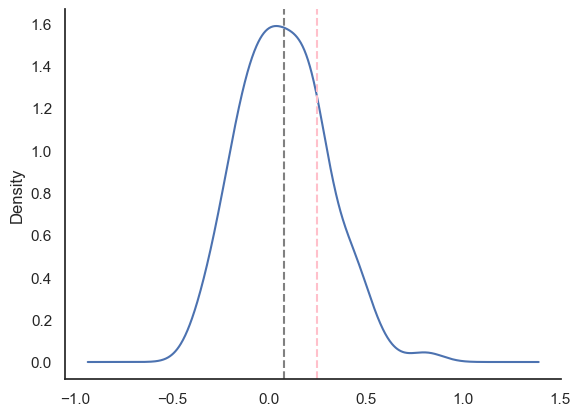

In [44]:
ax = TPAIRS.nmi.plot.kde()
ax.axvline(TPAIRS.nmi.mean(), ls='--', c='gray')
ax.axvline(nmi_thresh, ls='--', c='pink')
sns.despine()
plt.show()

## Build a Web Graph

In [48]:
TOPICS['group'].unique()


<StringArray>
[ 'Narrative Elements',       'Magic Systems', 'Application Domains',
  'Cross-Author Works']
Length: 4, dtype: str

In [49]:
G = nx.Graph()
for i, r in TOPICS.iterrows():
    G.add_node(i, label=r['label'], group=r['group'])
    
for i, r in TPAIRS[TPAIRS.nmi > nmi_thresh].iterrows():
    G.add_edge(i[0], i[1], weight=r.nmi)
pos = nx.spring_layout(G)
GROUP_COLORS = {
    'Narrative Elements': 'tab:blue',
    'Magic Systems': 'tab:orange',
    'Application Domains': 'tab:green',
    'Cross-Author Works': 'tab:red',
}

In [50]:
POS = pd.DataFrame(pos).T.join(TOPICS)

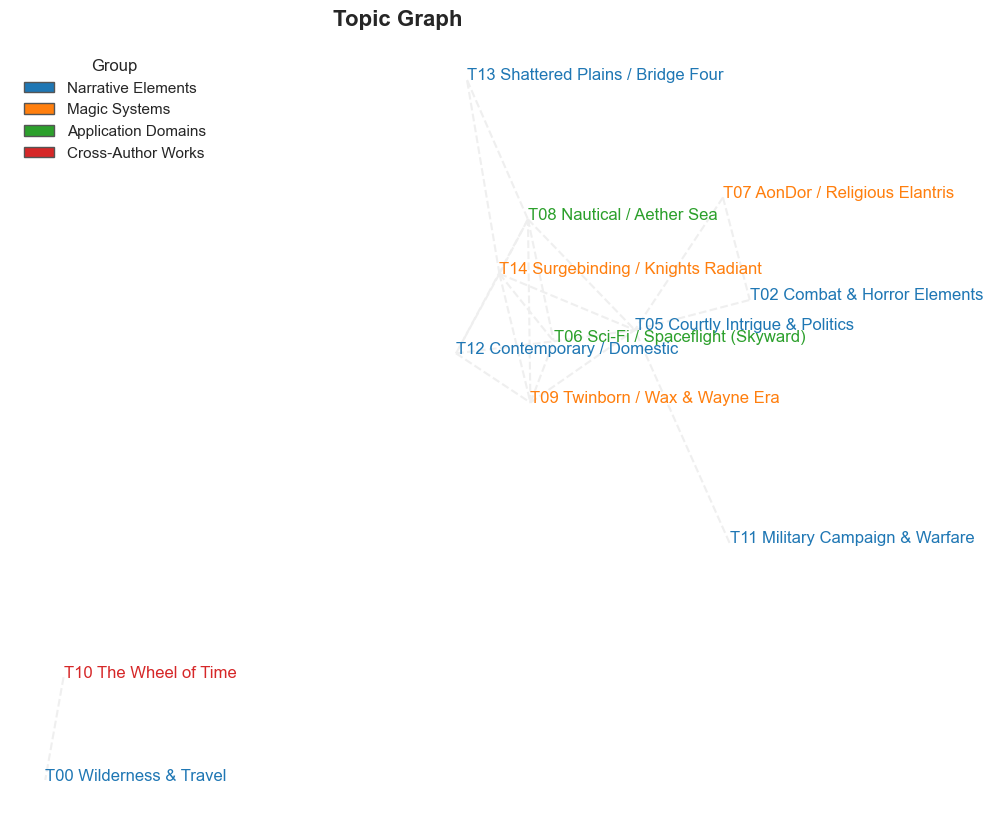

In [56]:
fig, ax = plt.subplots(figsize=(10,10))
for i, r in POS.iterrows():
    c = GROUP_COLORS[TOPICS.loc[i].group]
    ax.annotate(r['label'], xy=(r[0], r[1]), c=c)
for src, dst in G.edges:
    e = POS.loc[[dst,src], [0,1]]
    plt.plot(e[0].values, e[1].values, c='#EFEFEF', ls='--')
legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor='#555555', label=group)
    for group, color in GROUP_COLORS.items()
]
ax.legend(handles=legend_handles, loc='upper left',
          title='Group', frameon=False)
ax.set_title('Topic Graph', fontsize=16, fontweight='bold', pad=14)

plt.axis('off')
plt.savefig(directory_path + '/topic-graph.png', dpi=300, bbox_inches='tight')
plt.show()
